# CO3133 - Text Classification with Jigsaw Toxic Comment

This notebook implements the full **text classification** pipeline for Assignment 1.

## Dataset description
- **Dataset:** Jigsaw Toxic Comment Classification Challenge
- **Task:** **multi-label** classification with 6 target labels
- **Labels:** `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`
- **Input:** one user comment
- **Output:** a 6-dimensional multi-hot prediction vector

## Notebook structure
1. Resolve project paths from the Assignment 1 folder
2. Configure dataset paths and training hyperparameters
3. Extract and validate the raw Kaggle archive
4. Use the official Kaggle test split and create a validation split from `train.csv`
5. Fine-tune **BERT**
6. Train an **LSTM** baseline
7. Export metrics, plots, and error-analysis artifacts.

**Split policy:** `test.csv` + `test_labels.csv` are used as the official test set. A validation split is created from `train.csv` only.


# 1. EDA

### Dependency Setup

In [1]:
# Run this cell only if your environment is missing the required packages.
%pip install -q numpy pandas matplotlib seaborn requests torch scikit-learn transformers iterative-stratification

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\HAD\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Import Libraries And Resolve Paths

In [1]:
import os
from pathlib import Path
import copy
import json
import math
import random
import re
import warnings
import zipfile
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

warnings.filterwarnings("ignore")


def find_btl1_root() -> Path:
    # Resolve the BTL1 folder from the current working directory.
    # This keeps the notebook independent from any unrelated root marker file.
    for base in [Path.cwd(), *Path.cwd().parents]:
        if base.name == "btl1" and (base / "data").exists() and (base / "artifacts").exists():
            return base
        candidate = base / "btl1"
        if candidate.exists() and (candidate / "data").exists() and (candidate / "artifacts").exists():
            return candidate
    raise FileNotFoundError("Could not locate the btl1 directory. Run the notebook from the repo root or from inside btl1/.")


BTL1_ROOT = find_btl1_root()
REPO_ROOT = BTL1_ROOT.parent
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"BTL1 root: {BTL1_ROOT}")
print(f"Device: {DEVICE}")


C:\Users\HAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BTL1 root: d:\DeepLearning\btl1
Device: cuda


### Configure Dataset Paths

In [2]:
TEXT_DIR = BTL1_ROOT / "data" / "text" / "jigsaw"
SOURCE_DIR = TEXT_DIR / "source"
RAW_DIR = TEXT_DIR / "raw"
PROCESSED_DIR = TEXT_DIR / "processed"
ARTIFACT_DIR = BTL1_ROOT / "artifacts" / "text"
DOWNLOAD_ARTIFACT_DIR = ARTIFACT_DIR / "downloads"

ZIP_PATH = SOURCE_DIR / "jigsaw-toxic-comment-classification-challenge.zip"
JIGSAW_DRIVE_URL = "https://drive.google.com/file/d/1FQRhMwooipBqpF_caFpANUAZfFhF1xOu/view?usp=sharing"
LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

SEED = 42
VAL_RATIO = 0.10 
MAX_ROWS = None   
REBUILD_PROCESSED_TEXT = False
DOWNLOAD_IF_MISSING = True
AUTO_DOWNLOAD_TEXT_CHECKPOINTS_IF_MISSING = False
TEXT_CHECKPOINT_BUNDLE_URL = None
TEXT_CHECKPOINT_BUNDLE_FILE_ID = None
TEXT_CHECKPOINT_BUNDLE_NAME = None
TEXT_CHECKPOINT_BUNDLE_PATH = None
TEXT_BEST_CHECKPOINT_FILES = ["bert_multilabel_best.pt", "lstm_multilabel_best.pt"]
TEXT_CHECKPOINT_ROOT = ARTIFACT_DIR / "checkpoints"
BERT_CHECKPOINT_DIR = TEXT_CHECKPOINT_ROOT / "bert_full_finetune"
BERT_HEAD_ONLY_CHECKPOINT_DIR = TEXT_CHECKPOINT_ROOT / "bert_head_only_weighted"
LSTM_CHECKPOINT_DIR = TEXT_CHECKPOINT_ROOT / "lstm_weighted"

for folder in [SOURCE_DIR, RAW_DIR, PROCESSED_DIR, ARTIFACT_DIR, DOWNLOAD_ARTIFACT_DIR, TEXT_CHECKPOINT_ROOT, BERT_CHECKPOINT_DIR, BERT_HEAD_ONLY_CHECKPOINT_DIR, LSTM_CHECKPOINT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Source zip: {ZIP_PATH}")
print(f"Drive mirror: {JIGSAW_DRIVE_URL}")
print(f"Raw dir: {RAW_DIR}")
print(f"Processed dir: {PROCESSED_DIR}")
print(f"Artifact dir: {ARTIFACT_DIR}")
print("Checkpoint bundle cache: disabled for fresh training runs")


WANDB_ENABLED = True
WANDB_PROJECT = "DeepLearning-BTL1"
WANDB_ENTITY = None
WANDB_MODE = None
WANDB_API_KEY = "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"


Source zip: d:\DeepLearning\btl1\data\text\jigsaw\source\jigsaw-toxic-comment-classification-challenge.zip
Drive mirror: https://drive.google.com/file/d/1FQRhMwooipBqpF_caFpANUAZfFhF1xOu/view?usp=sharing
Raw dir: d:\DeepLearning\btl1\data\text\jigsaw\raw
Processed dir: d:\DeepLearning\btl1\data\text\jigsaw\processed
Artifact dir: d:\DeepLearning\btl1\artifacts\text
Checkpoint bundle cache: d:\DeepLearning\btl1\artifacts\text\downloads\text_best_checkpoints.zip


### Configure Model Hyperparameters

In [3]:
BERT_CFG = {
    "model_name": "bert-base-uncased",
    "max_length": 192,
    "batch_size": 16,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "epochs": 5,
}

BERT_HEAD_ONLY_CFG = {
    **BERT_CFG,
    "lr": 5e-4,
    "epochs": 5,
}

LSTM_CFG = {
    "batch_size": 64,
    "embed_dim": 200,
    "hidden_dim": 128,
    "dropout": 0.3,
    "lr": 1e-3,
    "epochs": 5,
    "max_length": 300,
    "max_vocab": None,
    "min_freq": 1,
}

PATIENCE = 2

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


### Define Utility Functions

In [4]:
def extract_drive_file_id(url: str) -> str:
    patterns = [r"/file/d/([A-Za-z0-9_-]+)", r"[?&]id=([A-Za-z0-9_-]+)"]
    for pattern in patterns:
        match = re.search(pattern, url)
        if match:
            return match.group(1)
    raise ValueError(f"Could not parse a Google Drive file id from: {url}")


def download_google_drive_if_missing(share_url: str, target: Path):
    target.parent.mkdir(parents=True, exist_ok=True)
    if target.exists():
        print(f"Source archive already exists: {target}")
        return target
    if not DOWNLOAD_IF_MISSING:
        raise FileNotFoundError(f"Missing source archive and auto-download is disabled: {target}")

    file_id = extract_drive_file_id(share_url)
    base_url = "https://drive.google.com/uc?export=download"
    session = requests.Session()
    response = session.get(base_url, params={"id": file_id}, stream=True)
    response.raise_for_status()

    for key, value in response.cookies.items():
        if key.startswith("download_warning"):
            response.close()
            response = session.get(base_url, params={"id": file_id, "confirm": value}, stream=True)
            response.raise_for_status()
            break

    print(f"Downloading Jigsaw archive from Google Drive -> {target}")
    with target.open("wb") as handle:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                handle.write(chunk)
    response.close()
    return target


def extract_zip(archive_path: Path, destination: Path):
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path, "r") as handle:
        handle.extractall(destination)


def extract_jigsaw_dataset(zip_path: Path, raw_dir: Path):
    train_candidates = list(raw_dir.rglob("train.csv"))
    test_candidates = list(raw_dir.rglob("test.csv"))
    labels_candidates = list(raw_dir.rglob("test_labels.csv"))
    if train_candidates and test_candidates and labels_candidates:
        print("Raw Jigsaw files already exist. Skipping extraction.")
        return

    if not zip_path.exists():
        raise FileNotFoundError(f"Missing source archive: {zip_path}")

    stage_dir = raw_dir / "stage_1"
    extract_zip(zip_path, stage_dir)

    nested_archives = sorted(stage_dir.glob("*.zip"))
    if not nested_archives:
        raise FileNotFoundError("No nested archives were found inside the Kaggle download.")

    for nested_zip in nested_archives:
        target_dir = raw_dir / nested_zip.stem
        if list(target_dir.rglob("*.csv")):
            continue
        extract_zip(nested_zip, target_dir)


def find_one(root: Path, name: str) -> Path:
    matches = sorted(path for path in root.rglob(name) if path.is_file())
    if not matches:
        raise FileNotFoundError(f"Could not find {name} under {root}")
    return matches[0]


def get_csv_paths(raw_dir: Path) -> dict[str, Path]:
    return {
        "train": find_one(raw_dir, "train.csv"),
        "test": find_one(raw_dir, "test.csv"),
        "test_labels": find_one(raw_dir, "test_labels.csv"),
        "sample_submission": find_one(raw_dir, "sample_submission.csv"),
    }



def ensure_text_checkpoints_available(required_files: list[str] | None = None) -> list[Path]:
    required_names = required_files or TEXT_BEST_CHECKPOINT_FILES
    required_paths = [ARTIFACT_DIR / name for name in required_names]
    missing_paths = [path for path in required_paths if not path.exists()]
    if not missing_paths:
        print("Requested text checkpoints already exist locally.")
        return required_paths

    if not AUTO_DOWNLOAD_TEXT_CHECKPOINTS_IF_MISSING:
        missing_names = ", ".join(path.name for path in missing_paths)
        raise FileNotFoundError(
            f"Missing text checkpoints: {missing_names}. Enable AUTO_DOWNLOAD_TEXT_CHECKPOINTS_IF_MISSING or place them in {ARTIFACT_DIR}."
        )

    if TEXT_CHECKPOINT_BUNDLE_PATH is not None and TEXT_CHECKPOINT_BUNDLE_PATH.exists():
        print(f"Using cached text checkpoint bundle: {TEXT_CHECKPOINT_BUNDLE_PATH}")
    else:
        if not TEXT_CHECKPOINT_BUNDLE_URL:
            raise FileNotFoundError(
                "Missing text checkpoint bundle cache. Upload a local bundle or set a new TEXT_CHECKPOINT_BUNDLE_URL before enabling auto-download."
            )
        import gdown
        print("Downloading text checkpoint bundle from Google Drive...")
        gdown.download(url=TEXT_CHECKPOINT_BUNDLE_URL, output=str(TEXT_CHECKPOINT_BUNDLE_PATH), fuzzy=True, quiet=False)

    try:
        with zipfile.ZipFile(TEXT_CHECKPOINT_BUNDLE_PATH, "r") as zf:
            archive_names = sorted(name for name in zf.namelist() if not name.endswith("/"))
            expected_names = sorted(TEXT_BEST_CHECKPOINT_FILES)
            if archive_names != expected_names:
                raise ValueError(
                    "Text checkpoint bundle contents do not match the expected best checkpoints. "
                    f"Expected {expected_names}, found {archive_names}."
                )
            for member in expected_names:
                zf.extract(member, ARTIFACT_DIR)
    except zipfile.BadZipFile as exc:
        raise RuntimeError(f"Text checkpoint bundle is unreadable: {TEXT_CHECKPOINT_BUNDLE_PATH}") from exc

    unresolved = [path.name for path in required_paths if not path.exists()]
    if unresolved:
        raise FileNotFoundError(
            "Text checkpoint extraction completed but some required files are still missing: "
            + ", ".join(unresolved)
        )

    print("Recovered requested text checkpoints from bundle.")
    return required_paths

def normalize_text(text: str) -> str:
    text = str(text).replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def exact_match_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.all(y_true == y_pred, axis=1).mean())


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, loss_value: float) -> dict:
    return {
        "exact_match_accuracy": exact_match_score(y_true, y_pred),
        "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "loss": float(loss_value),
    }


def plot_history(history_df: pd.DataFrame, metric_col: str, title: str, output_path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[1].plot(history_df["epoch"], history_df[metric_col], marker="o", color="#17365d")
    axes[1].set_title(metric_col)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel(metric_col)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)


def build_error_payload(y_true: np.ndarray, y_pred: np.ndarray, labels: list[str]) -> dict:
    payload = {
        "exact_match_failures": int((~np.all(y_true == y_pred, axis=1)).sum()),
        "total_examples": int(y_true.shape[0]),
        "total_true_positive_labels": int(y_true.sum()),
        "total_predicted_positive_labels": int(y_pred.sum()),
        "per_label": [],
    }

    for idx, label in enumerate(labels):
        truth = y_true[:, idx]
        pred = y_pred[:, idx]
        tp = int(((truth == 1) & (pred == 1)).sum())
        fp = int(((truth == 0) & (pred == 1)).sum())
        fn = int(((truth == 1) & (pred == 0)).sum())
        tn = int(((truth == 0) & (pred == 0)).sum())
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
        payload["per_label"].append({
            "label": label,
            "support": int(truth.sum()),
            "predicted_positive": int(pred.sum()),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    payload["hardest_labels"] = [item["label"] for item in sorted(payload["per_label"], key=lambda item: item["f1"])[:3]]
    return payload


# 2. DataLoader And Split Preparation

### Prepare The Official Data Splits

In [5]:
download_google_drive_if_missing(JIGSAW_DRIVE_URL, ZIP_PATH)
extract_jigsaw_dataset(ZIP_PATH, RAW_DIR)
csv_paths = get_csv_paths(RAW_DIR)

train_raw_df = pd.read_csv(csv_paths["train"])
test_inputs_df = pd.read_csv(csv_paths["test"])
test_labels_df = pd.read_csv(csv_paths["test_labels"])

if MAX_ROWS is not None:
    train_raw_df = train_raw_df.head(MAX_ROWS).copy()

train_raw_df["comment_text"] = train_raw_df["comment_text"].fillna("").map(normalize_text)
train_raw_df["char_length"] = train_raw_df["comment_text"].str.len()
train_raw_df["word_length"] = train_raw_df["comment_text"].str.split().str.len()
train_raw_df["label_count"] = train_raw_df[LABELS].sum(axis=1)

official_test_df = test_inputs_df.merge(test_labels_df, on="id", how="inner")
official_test_df = official_test_df[(official_test_df[LABELS] >= 0).all(axis=1)].copy()
if MAX_ROWS is not None:
    official_test_df = official_test_df.head(MAX_ROWS).copy()
official_test_df["comment_text"] = official_test_df["comment_text"].fillna("").map(normalize_text)
official_test_df["char_length"] = official_test_df["comment_text"].str.len()
official_test_df["word_length"] = official_test_df["comment_text"].str.split().str.len()
official_test_df["label_count"] = official_test_df[LABELS].sum(axis=1)

processed_train_path = PROCESSED_DIR / "train.csv"
processed_val_path = PROCESSED_DIR / "val.csv"
processed_test_path = PROCESSED_DIR / "test.csv"

if all(path.exists() for path in [processed_train_path, processed_val_path, processed_test_path]) and not REBUILD_PROCESSED_TEXT:
    train_df_split = pd.read_csv(processed_train_path)
    val_df = pd.read_csv(processed_val_path)
    test_df = pd.read_csv(processed_test_path)
    print("Loaded existing processed text splits.")
else:
    model_df = train_raw_df[["id", "comment_text"] + LABELS].copy().reset_index(drop=True)
    y = model_df[LABELS].to_numpy(dtype=np.int64)
    splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=VAL_RATIO, random_state=SEED)
    train_idx, val_idx = next(splitter.split(model_df[["comment_text"]], y))
    train_df_split = model_df.iloc[train_idx].reset_index(drop=True)
    val_df = model_df.iloc[val_idx].reset_index(drop=True)
    test_df = official_test_df[["id", "comment_text"] + LABELS].copy().reset_index(drop=True)
    train_df_split.to_csv(processed_train_path, index=False)
    val_df.to_csv(processed_val_path, index=False)
    test_df.to_csv(processed_test_path, index=False)
    print("Saved processed text splits with iterative multilabel stratification.")

print({"train": len(train_df_split), "val": len(val_df), "test_official": len(test_df)})

display(pd.DataFrame({
    "stat": ["train rows", "official test rows", "avg chars", "median chars", "multi-label rows"],
    "value": [
        len(train_raw_df),
        len(official_test_df),
        round(train_raw_df["char_length"].mean(), 2),
        round(train_raw_df["char_length"].median(), 2),
        int((train_raw_df["label_count"] > 1).sum()),
    ],
}))

Source archive already exists: d:\DeepLearning\btl1\data\text\jigsaw\source\jigsaw-toxic-comment-classification-challenge.zip
Raw Jigsaw files already exist. Skipping extraction.


Loaded existing processed text splits.
{'train': 143613, 'val': 15958, 'test_official': 63978}


,stat,value
0,train rows,159571.00
1,official test rows,63978.00
2,avg chars,390.92
3,median chars,204.00
4,multi-label rows,9865.00


### Label Imbalance, Co-Occurrence, And Correlation
Review raw label imbalance and the correlation structure between toxic labels before discussing split strategy and loss weighting.

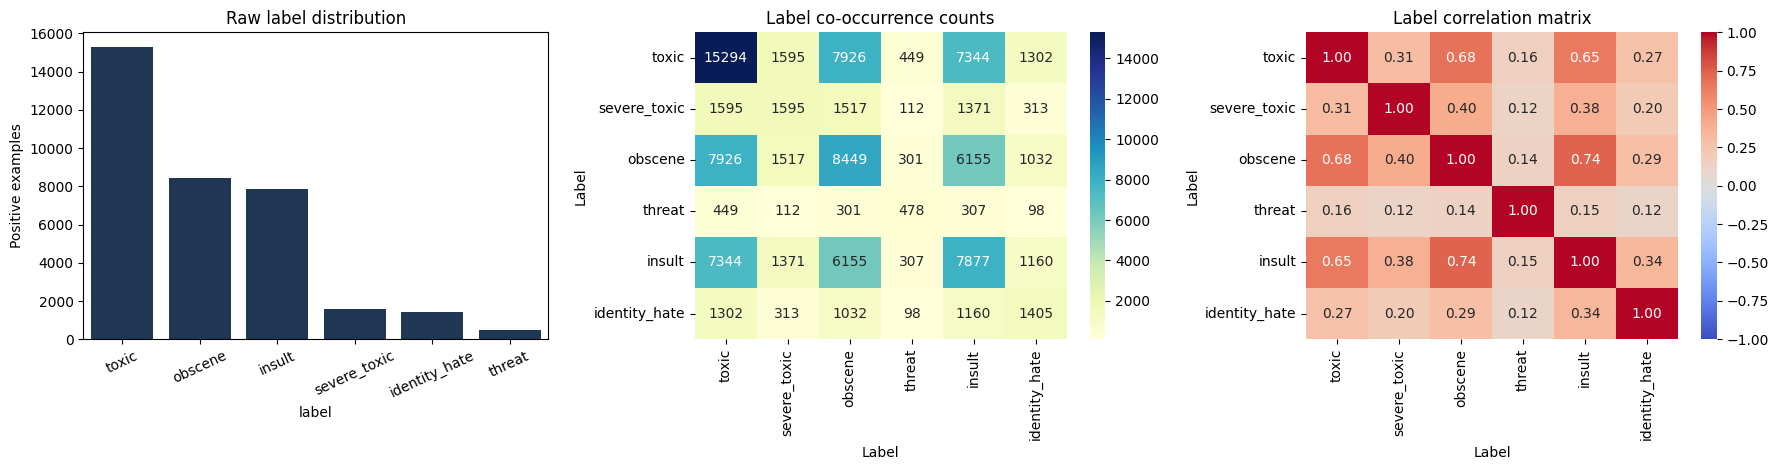

,label,positive_examples,positive_rate_pct
0,toxic,15294,9.5844
2,obscene,8449,5.2948
4,insult,7877,4.9364
1,severe_toxic,1595,0.9996
5,identity_hate,1405,0.8805
3,threat,478,0.2996


split,test,train,val
label,,,
identity_hate,1.113,0.876,0.921
insult,5.357,4.934,4.957
obscene,5.769,5.301,5.239
severe_toxic,0.574,1.008,0.927
threat,0.330,0.307,0.232
toxic,9.519,9.619,9.274


In [6]:
label_counts = train_raw_df[LABELS].sum().sort_values(ascending=False)
label_dist_df = pd.DataFrame({
    "label": LABELS,
    "positive_examples": [int(train_raw_df[label].sum()) for label in LABELS],
    "positive_rate_pct": [float(train_raw_df[label].mean() * 100.0) for label in LABELS],
}).sort_values("positive_examples", ascending=False)
label_dist_df.to_csv(ARTIFACT_DIR / "text_label_distribution.csv", index=False)

cooccurrence_df = train_raw_df[LABELS].T.dot(train_raw_df[LABELS]).astype(int)
cooccurrence_df.to_csv(ARTIFACT_DIR / "text_label_cooccurrence.csv")

correlation_df = train_raw_df[LABELS].corr().round(4)
correlation_df.to_csv(ARTIFACT_DIR / "text_label_correlation.csv")

split_balance_rows = []
for split_name, frame in {"train": train_df_split, "val": val_df, "test": test_df}.items():
    for label in LABELS:
        split_balance_rows.append({
            "split": split_name,
            "label": label,
            "positive_examples": int(frame[label].sum()),
            "positive_rate_pct": float(frame[label].mean() * 100.0),
        })
split_balance_df = pd.DataFrame(split_balance_rows)
split_balance_df.to_csv(ARTIFACT_DIR / "text_split_label_balance.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
sns.barplot(data=label_dist_df, x="label", y="positive_examples", color="#17365d", ax=axes[0])
axes[0].set_title("Raw label distribution")
axes[0].set_ylabel("Positive examples")
axes[0].tick_params(axis="x", rotation=25)

sns.heatmap(cooccurrence_df, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Label co-occurrence counts")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Label")

sns.heatmap(correlation_df, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1.0, vmax=1.0, ax=axes[2])
axes[2].set_title("Label correlation matrix")
axes[2].set_xlabel("Label")
axes[2].set_ylabel("Label")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "text_label_structure_eda.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

display(label_dist_df.round(4))
display(split_balance_df.pivot(index="label", columns="split", values="positive_rate_pct").round(3))

### Vocabulary Size And Coverage Analysis

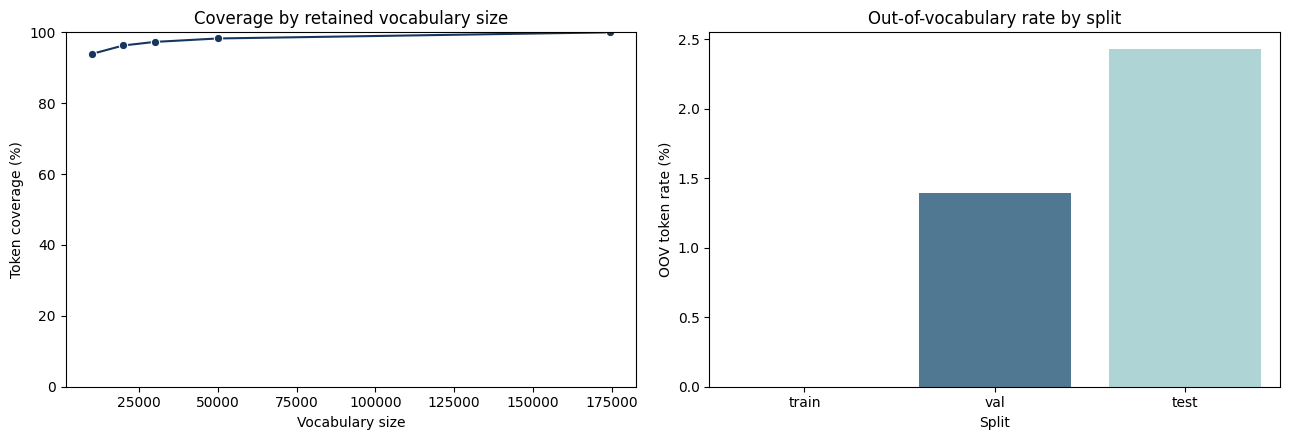

,stat,value
0,Raw unique tokens in train split,174517
1,Eligible unique tokens with min_freq >= 1,174517
2,Configured max_vocab,full_eligible
3,Effective vocab size including <pad>/<unk>,174519


,top_k,effective_vocab_size,token_coverage_pct
0,10000,10000,93.884
1,20000,20000,96.286
2,30000,30000,97.296
3,50000,50000,98.269
4,174519,174519,100.000


,split,total_tokens,oov_tokens,oov_rate_pct,sequence_with_oov_pct
0,train,9666413,0,0.000,0.000
1,val,1032183,14418,1.397,32.817
2,test,4022074,97700,2.429,37.980


Current LSTM uses a word-level regex tokenizer with max_vocab=full_eligible and min_freq=1. Coverage at the current setting is 100.00% of eligible train tokens.


In [7]:
from collections import Counter
import re

vocab_token_pattern = re.compile(r"[a-z']+")

def vocab_tokenize(text: str) -> list[str]:
    return vocab_token_pattern.findall(str(text).lower())

train_texts_for_vocab = train_df_split["comment_text"].fillna("").astype(str)
val_texts_for_vocab = val_df["comment_text"].fillna("").astype(str)
test_texts_for_vocab = test_df["comment_text"].fillna("").astype(str)

train_counter = Counter()
for text in train_texts_for_vocab:
    train_counter.update(vocab_tokenize(text))

raw_unique_tokens = len(train_counter)
eligible_tokens = [(token, freq) for token, freq in train_counter.most_common() if freq >= LSTM_CFG["min_freq"]]
eligible_unique_tokens = len(eligible_tokens)
configured_max_vocab = LSTM_CFG["max_vocab"] if LSTM_CFG["max_vocab"] is not None else "full_eligible"
current_vocab_size = eligible_unique_tokens + 2 if LSTM_CFG["max_vocab"] is None else min(LSTM_CFG["max_vocab"], eligible_unique_tokens + 2)

def token_coverage(top_k: int) -> float:
    limited = eligible_tokens[: max(0, top_k - 2)]
    covered = sum(freq for _, freq in limited)
    total = sum(freq for _, freq in eligible_tokens)
    return covered / total if total else 0.0

coverage_rows = []
for top_k in [10000, 20000, 30000, 50000, eligible_unique_tokens + 2]:
    effective_vocab_size = min(top_k, eligible_unique_tokens + 2)
    coverage_rows.append({
        "top_k": top_k,
        "effective_vocab_size": effective_vocab_size,
        "token_coverage_pct": token_coverage(top_k) * 100.0,
    })
coverage_df = pd.DataFrame(coverage_rows)
coverage_df.to_csv(ARTIFACT_DIR / "text_vocab_coverage_summary.csv", index=False)

selected_vocab_tokens = {token for token, _ in eligible_tokens} if LSTM_CFG["max_vocab"] is None else {token for token, _ in eligible_tokens[: max(0, LSTM_CFG["max_vocab"] - 2)]}

def split_oov_stats(split_name: str, texts: pd.Series):
    total_tokens = 0
    oov_tokens = 0
    total_sequences = 0
    oov_sequences = 0
    for text in texts:
        tokens = vocab_tokenize(text)
        if not tokens:
            continue
        total_sequences += 1
        total_tokens += len(tokens)
        current_oov = sum(token not in selected_vocab_tokens for token in tokens)
        oov_tokens += current_oov
        if current_oov > 0:
            oov_sequences += 1
    return {
        "split": split_name,
        "total_tokens": int(total_tokens),
        "oov_tokens": int(oov_tokens),
        "oov_rate_pct": (oov_tokens / total_tokens * 100.0) if total_tokens else 0.0,
        "sequence_with_oov_pct": (oov_sequences / total_sequences * 100.0) if total_sequences else 0.0,
    }

oov_df = pd.DataFrame([
    split_oov_stats("train", train_texts_for_vocab),
    split_oov_stats("val", val_texts_for_vocab),
    split_oov_stats("test", test_texts_for_vocab),
])
oov_df.to_csv(ARTIFACT_DIR / "text_vocab_oov_summary.csv", index=False)

summary_df = pd.DataFrame({
    "stat": [
        "Raw unique tokens in train split",
        f"Eligible unique tokens with min_freq >= {LSTM_CFG['min_freq']}",
        "Configured max_vocab",
        "Effective vocab size including <pad>/<unk>",
    ],
    "value": [
        raw_unique_tokens,
        eligible_unique_tokens,
        configured_max_vocab,
        current_vocab_size,
    ],
})
summary_df.to_csv(ARTIFACT_DIR / "text_vocab_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(data=coverage_df, x="effective_vocab_size", y="token_coverage_pct", marker="o", ax=axes[0], color="#17365d")
axes[0].set_title("Coverage by retained vocabulary size")
axes[0].set_xlabel("Vocabulary size")
axes[0].set_ylabel("Token coverage (%)")
axes[0].set_ylim(0, 100)

sns.barplot(data=oov_df, x="split", y="oov_rate_pct", palette=["#17365d", "#457b9d", "#a8dadc"], ax=axes[1])
axes[1].set_title("Out-of-vocabulary rate by split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("OOV token rate (%)")

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "text_vocab_eda.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

display(summary_df)
display(coverage_df.round(3))
display(oov_df.round(3))
print(
    f"Current LSTM uses a word-level regex tokenizer with max_vocab={configured_max_vocab} and min_freq={LSTM_CFG['min_freq']}. "
    f"Coverage at the current setting is {coverage_df.loc[coverage_df['effective_vocab_size'] == current_vocab_size, 'token_coverage_pct'].iloc[-1]:.2f}% of eligible train tokens."
)


# 3. Model

### Fine-Tune BERT

In [7]:
class TextDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        labels = row[LABELS].astype(np.float32).to_numpy()
        return row["comment_text"], labels


tokenizer = AutoTokenizer.from_pretrained(BERT_CFG["model_name"])


def collate_batch(batch):
    texts = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch], dtype=torch.float32)
    encoded = tokenizer(texts, padding=True, truncation=True, max_length=BERT_CFG["max_length"], return_tensors="pt")
    encoded["labels"] = labels
    return encoded


train_loader = DataLoader(TextDataset(train_df_split), batch_size=BERT_CFG["batch_size"], shuffle=True, num_workers=0, collate_fn=collate_batch)
val_loader = DataLoader(TextDataset(val_df), batch_size=BERT_CFG["batch_size"], shuffle=False, num_workers=0, collate_fn=collate_batch)
test_loader = DataLoader(TextDataset(test_df), batch_size=BERT_CFG["batch_size"], shuffle=False, num_workers=0, collate_fn=collate_batch)

train_positive = train_df_split[LABELS].sum(axis=0).to_numpy(dtype=np.float32)
train_negative = len(train_df_split) - train_positive
POS_WEIGHT = torch.tensor(np.clip(train_negative / np.clip(train_positive, a_min=1.0, a_max=None), a_min=1.0, a_max=None), dtype=torch.float32, device=DEVICE)
print("BERT pos_weight:", dict(zip(LABELS, POS_WEIGHT.detach().cpu().numpy().round(2).tolist())))


def run_epoch(model, loader, optimizer=None, scheduler=None, pos_weight=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for batch in loader:
            labels = batch.pop("labels").to(DEVICE)
            batch = {key: value.to(DEVICE) for key, value in batch.items()}
            if training:
                optimizer.zero_grad()
            outputs = model(**batch)
            logits = outputs.logits
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) if pos_weight is not None else nn.BCEWithLogitsLoss()
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()
            preds = (torch.sigmoid(logits) >= 0.5).int().detach().cpu().numpy()
            y_pred.append(preds)
            y_true.append(labels.detach().cpu().int().numpy())
            total_loss += float(loss.item()) * labels.size(0)

    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)
    avg_loss = total_loss / len(loader.dataset)
    return compute_metrics(y_true, y_pred, avg_loss), y_true, y_pred


def build_bert_model(head_only: bool = False):
    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_CFG["model_name"],
        num_labels=len(LABELS),
        problem_type="multi_label_classification",
    ).to(DEVICE)
    if head_only:
        base_model = getattr(model, model.base_model_prefix)
        for param in base_model.parameters():
            param.requires_grad = False
    return model


def count_trainable_parameters(model: nn.Module) -> tuple[int, int]:
    total = sum(param.numel() for param in model.parameters())
    trainable = sum(param.numel() for param in model.parameters() if param.requires_grad)
    return total, trainable


def show_notebook_alert(title: str, message: str, level: str = "warning") -> None:
    color_map = {
        "warning": ("#78350f", "#fef3c7", "#f59e0b"),
        "error": ("#991b1b", "#fee2e2", "#ef4444"),
        "info": ("#1d4ed8", "#dbeafe", "#3b82f6"),
    }
    text_color, bg_color, border_color = color_map.get(level, color_map["warning"])
    html = (
        f"<div style='margin:12px 0;padding:12px 14px;border-left:4px solid {border_color};"
        f"background:{bg_color};color:{text_color};border-radius:8px;'>"
        f"<strong>{title}</strong><br>{message}</div>"
    )
    try:
        from IPython.display import HTML, display
        display(HTML(html))
    except Exception:
        print(f"{title}: {message}")


class WandbLogger:
    def __init__(self, run_name: str, config: dict, enabled: bool):
        self.enabled = False
        self.run = None
        self.mode = None
        if not enabled:
            return
        try:
            import wandb  # type: ignore
        except ImportError:
            message = "wandb is not installed in the current kernel. Training will continue without dashboard logging."
            print(message)
            show_notebook_alert("W&B logging disabled", message, level="warning")
            return

        init_kwargs = {
            "project": WANDB_PROJECT,
            "name": run_name,
            "config": config,
            "dir": str(ARTIFACT_DIR),
        }
        if WANDB_ENTITY:
            init_kwargs["entity"] = WANDB_ENTITY
        if WANDB_MODE:
            init_kwargs["mode"] = WANDB_MODE
        if WANDB_API_KEY:
            os.environ["WANDB_API_KEY"] = WANDB_API_KEY
        try:
            self.run = wandb.init(**init_kwargs)
        except Exception as exc:
            message = f"wandb init failed for {run_name}. Training will continue without dashboard logging. Error: {exc}"
            print(message)
            show_notebook_alert("W&B logging disabled", message, level="warning")
            return

        self.mode = getattr(self.run.settings, "mode", init_kwargs.get("mode", "online"))
        self.enabled = True
        print(f"wandb logging enabled for {run_name} (mode={self.mode}).")

    def log(self, payload: dict, step: int | None = None) -> None:
        if self.enabled and self.run is not None:
            self.run.log(payload, step=step)

    def finish(self) -> None:
        if self.enabled and self.run is not None:
            self.run.finish()


def to_cpu_checkpoint_object(value):
    if torch.is_tensor(value):
        return value.detach().cpu()
    if isinstance(value, dict):
        return {key: to_cpu_checkpoint_object(item) for key, item in value.items()}
    if isinstance(value, list):
        return [to_cpu_checkpoint_object(item) for item in value]
    if isinstance(value, tuple):
        return tuple(to_cpu_checkpoint_object(item) for item in value)
    return copy.deepcopy(value)


def move_optimizer_state_to_device(optimizer, device):
    if optimizer is None:
        return
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)


def save_resume_checkpoint(
    resume_path: Path,
    epoch_path: Path,
    model: nn.Module,
    optimizer,
    scheduler,
    epoch: int,
    best_score: float,
    patience_left: int,
    history_rows: list[dict],
    config: dict,
) -> None:
    payload = {
        "epoch": int(epoch),
        "model_state_dict": to_cpu_checkpoint_object(model.state_dict()),
        "optimizer_state_dict": to_cpu_checkpoint_object(optimizer.state_dict()) if optimizer is not None else None,
        "scheduler_state_dict": to_cpu_checkpoint_object(scheduler.state_dict()) if scheduler is not None else None,
        "best_score": float(best_score),
        "patience_left": int(patience_left),
        "history_rows": copy.deepcopy(history_rows),
        "config": copy.deepcopy(config),
        "labels": LABELS,
    }
    resume_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, resume_path)
    torch.save(payload, epoch_path)


def restore_resume_checkpoint(resume_path: Path, model: nn.Module, optimizer=None, scheduler=None) -> dict:
    checkpoint = torch.load(resume_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        move_optimizer_state_to_device(optimizer, DEVICE)
    if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    return {
        "start_epoch": int(checkpoint.get("epoch", 0)) + 1,
        "best_score": float(checkpoint.get("best_score", -math.inf)),
        "patience_left": int(checkpoint.get("patience_left", PATIENCE)),
        "history_rows": list(checkpoint.get("history_rows", [])),
    }


model = build_bert_model(head_only=False)
optimizer = torch.optim.AdamW([param for param in model.parameters() if param.requires_grad], lr=BERT_CFG["lr"], weight_decay=BERT_CFG["weight_decay"])
total_steps = len(train_loader) * BERT_CFG["epochs"]
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=max(total_steps // 10, 1), num_training_steps=total_steps)

ckpt_path = ARTIFACT_DIR / "bert_multilabel_best.pt"
history_path = ARTIFACT_DIR / "bert_history.csv"
curve_path = ARTIFACT_DIR / "bert_learning_curves.png"
resume_path = BERT_CHECKPOINT_DIR / "bert_full_resume.pt"

total_params, trainable_params = count_trainable_parameters(model)
print(f"BERT full fine-tune | trainable params={trainable_params:,} / {total_params:,} ({trainable_params / max(total_params, 1):.4%})")
bert_wandb_logger = WandbLogger("text_bert_full_finetune", {**BERT_CFG, "task": "text_multilabel", "variant": "full_finetune"}, WANDB_ENABLED)
if ckpt_path.exists():
    print("Loading cached BERT checkpoint and skipping retraining.")
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    history_df = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "val_micro_f1", "val_macro_f1"])
else:
    rows: list[dict] = []
    best_score = -math.inf
    patience_left = PATIENCE
    start_epoch = 1
    if resume_path.exists():
        resume_state = restore_resume_checkpoint(resume_path, model, optimizer, scheduler)
        start_epoch = resume_state["start_epoch"]
        best_score = resume_state["best_score"]
        patience_left = resume_state["patience_left"]
        rows = resume_state["history_rows"]
        print(f"Resuming BERT full fine-tune from epoch {start_epoch} using {resume_path.name}.")

    for epoch in range(start_epoch, BERT_CFG["epochs"] + 1):
        train_metrics, _, _ = run_epoch(model, train_loader, optimizer, scheduler, pos_weight=POS_WEIGHT)
        val_metrics, _, _ = run_epoch(model, val_loader, pos_weight=POS_WEIGHT)
        rows.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "val_micro_f1": val_metrics["micro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
        })
        bert_wandb_logger.log({
            "epoch": epoch,
            "bert_full/train_loss": train_metrics["loss"],
            "bert_full/val_loss": val_metrics["loss"],
            "bert_full/val_micro_f1": val_metrics["micro_f1"],
            "bert_full/val_macro_f1": val_metrics["macro_f1"],
        }, step=epoch)
        if val_metrics["micro_f1"] > best_score:
            best_score = val_metrics["micro_f1"]
            patience_left = PATIENCE
            torch.save({key: value.detach().cpu().clone() for key, value in model.state_dict().items()}, ckpt_path)
        else:
            patience_left -= 1

        epoch_path = BERT_CHECKPOINT_DIR / f"bert_full_epoch_{epoch:02d}.pt"
        save_resume_checkpoint(resume_path, epoch_path, model, optimizer, scheduler, epoch, best_score, patience_left, rows, BERT_CFG)
        pd.DataFrame(rows).to_csv(history_path, index=False)

        if patience_left <= 0:
            print("Early stopping triggered for BERT full fine-tune.")
            break

    if not ckpt_path.exists():
        raise RuntimeError("BERT training did not produce a valid checkpoint.")
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    history_df = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame(rows)

plot_history(history_df, "val_micro_f1", "BERT learning curves", curve_path)
print(f"BERT history CSV: {history_path}")
print(f"BERT learning curves: {curve_path}")
print(f"BERT best checkpoint: {ckpt_path}")
print(f"BERT resume checkpoint: {resume_path}")
bert_metrics, bert_y_true, bert_y_pred = run_epoch(model, test_loader, pos_weight=POS_WEIGHT)
bert_wandb_logger.log({
    "bert_full/test_loss": bert_metrics["loss"],
    "bert_full/test_exact_match_accuracy": bert_metrics["exact_match_accuracy"],
    "bert_full/test_micro_f1": bert_metrics["micro_f1"],
    "bert_full/test_macro_f1": bert_metrics["macro_f1"],
})
bert_wandb_logger.finish()
bert_metrics


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading cached BERT checkpoint and history.


{'exact_match_accuracy': 0.8544812279220982,
 'micro_precision': 0.500450291710717,
 'micro_recall': 0.8815698717064423,
 'micro_f1': 0.6384594250318455,
 'macro_precision': 0.4546272467517886,
 'macro_recall': 0.8224646666791723,
 'macro_f1': 0.5787241119433905,
 'loss': 0.13162880305700497}

### Train The BERT Head-Only Weighted Variant

This optional branch freezes the pretrained BERT encoder and trains only the classifier head with the same weighted BCE loss (`pos_weight`) used by the full fine-tuning branch. It is intended as a cleaner training-strategy comparison than comparing only `BERT` against `LSTM`.

In [ ]:
bert_head_only_model = build_bert_model(head_only=True)
head_only_total_params, head_only_trainable_params = count_trainable_parameters(bert_head_only_model)
print(f"BERT head-only weighted | trainable params={head_only_trainable_params:,} / {head_only_total_params:,} ({head_only_trainable_params / max(head_only_total_params, 1):.4%})")

head_only_optimizer = torch.optim.AdamW(
    [param for param in bert_head_only_model.parameters() if param.requires_grad],
    lr=BERT_HEAD_ONLY_CFG["lr"],
    weight_decay=BERT_HEAD_ONLY_CFG["weight_decay"],
)
head_only_total_steps = len(train_loader) * BERT_HEAD_ONLY_CFG["epochs"]
head_only_scheduler = get_linear_schedule_with_warmup(
    head_only_optimizer,
    num_warmup_steps=max(head_only_total_steps // 10, 1),
    num_training_steps=head_only_total_steps,
)

bert_head_only_ckpt_path = ARTIFACT_DIR / "bert_head_only_weighted_best.pt"
bert_head_only_history_path = ARTIFACT_DIR / "bert_head_only_weighted_history.csv"
bert_head_only_curve_path = ARTIFACT_DIR / "bert_head_only_weighted_learning_curves.png"
bert_head_only_resume_path = BERT_HEAD_ONLY_CHECKPOINT_DIR / "bert_head_only_weighted_resume.pt"
bert_head_only_wandb_logger = WandbLogger("text_bert_head_only_weighted", {**BERT_HEAD_ONLY_CFG, "task": "text_multilabel", "variant": "head_only_weighted"}, WANDB_ENABLED)

if bert_head_only_ckpt_path.exists():
    print("Loading cached BERT head-only weighted checkpoint and skipping retraining.")
    bert_head_only_model.load_state_dict(torch.load(bert_head_only_ckpt_path, map_location=DEVICE))
    bert_head_only_history_df = pd.read_csv(bert_head_only_history_path) if bert_head_only_history_path.exists() else pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "val_micro_f1", "val_macro_f1"])
else:
    rows: list[dict] = []
    best_score = -math.inf
    patience_left = PATIENCE
    start_epoch = 1
    if bert_head_only_resume_path.exists():
        resume_state = restore_resume_checkpoint(bert_head_only_resume_path, bert_head_only_model, head_only_optimizer, head_only_scheduler)
        start_epoch = resume_state["start_epoch"]
        best_score = resume_state["best_score"]
        patience_left = resume_state["patience_left"]
        rows = resume_state["history_rows"]
        print(f"Resuming BERT head-only weighted from epoch {start_epoch} using {bert_head_only_resume_path.name}.")

    for epoch in range(start_epoch, BERT_HEAD_ONLY_CFG["epochs"] + 1):
        train_metrics, _, _ = run_epoch(bert_head_only_model, train_loader, head_only_optimizer, head_only_scheduler, pos_weight=POS_WEIGHT)
        val_metrics, _, _ = run_epoch(bert_head_only_model, val_loader, pos_weight=POS_WEIGHT)
        rows.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "val_micro_f1": val_metrics["micro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
        })
        bert_head_only_wandb_logger.log({
            "epoch": epoch,
            "bert_head_only/train_loss": train_metrics["loss"],
            "bert_head_only/val_loss": val_metrics["loss"],
            "bert_head_only/val_micro_f1": val_metrics["micro_f1"],
            "bert_head_only/val_macro_f1": val_metrics["macro_f1"],
        }, step=epoch)
        if val_metrics["micro_f1"] > best_score:
            best_score = val_metrics["micro_f1"]
            patience_left = PATIENCE
            torch.save({key: value.detach().cpu().clone() for key, value in bert_head_only_model.state_dict().items()}, bert_head_only_ckpt_path)
        else:
            patience_left -= 1

        epoch_path = BERT_HEAD_ONLY_CHECKPOINT_DIR / f"bert_head_only_weighted_epoch_{epoch:02d}.pt"
        save_resume_checkpoint(bert_head_only_resume_path, epoch_path, bert_head_only_model, head_only_optimizer, head_only_scheduler, epoch, best_score, patience_left, rows, BERT_HEAD_ONLY_CFG)
        pd.DataFrame(rows).to_csv(bert_head_only_history_path, index=False)

        if patience_left <= 0:
            print("Early stopping triggered for BERT head-only weighted.")
            break

    if not bert_head_only_ckpt_path.exists():
        raise RuntimeError("BERT head-only weighted training did not produce a valid checkpoint.")
    bert_head_only_model.load_state_dict(torch.load(bert_head_only_ckpt_path, map_location=DEVICE))
    bert_head_only_history_df = pd.read_csv(bert_head_only_history_path) if bert_head_only_history_path.exists() else pd.DataFrame(rows)

plot_history(bert_head_only_history_df, "val_micro_f1", "BERT head-only weighted learning curves", bert_head_only_curve_path)
print(f"BERT head-only history CSV: {bert_head_only_history_path}")
print(f"BERT head-only learning curves: {bert_head_only_curve_path}")
print(f"BERT head-only best checkpoint: {bert_head_only_ckpt_path}")
print(f"BERT head-only resume checkpoint: {bert_head_only_resume_path}")
bert_head_only_metrics, bert_head_only_y_true, bert_head_only_y_pred = run_epoch(bert_head_only_model, test_loader, pos_weight=POS_WEIGHT)
bert_head_only_wandb_logger.log({
    "bert_head_only/test_loss": bert_head_only_metrics["loss"],
    "bert_head_only/test_exact_match_accuracy": bert_head_only_metrics["exact_match_accuracy"],
    "bert_head_only/test_micro_f1": bert_head_only_metrics["micro_f1"],
    "bert_head_only/test_macro_f1": bert_head_only_metrics["macro_f1"],
})
bert_head_only_wandb_logger.finish()
bert_head_only_metrics


### Train The LSTM Baseline

In [8]:
token_pattern = re.compile(r"[a-z']+")


def tokenize(text: str) -> list[str]:
    return token_pattern.findall(text.lower())


def build_vocab(texts, max_size=None, min_freq=1):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, freq in counter.most_common():
        if freq < min_freq:
            break
        if max_size is not None and len(vocab) >= max_size:
            break
        vocab[word] = len(vocab)
    return vocab


def encode_text(text: str, vocab: dict[str, int], max_length: int):
    ids = [vocab.get(token, vocab["<unk>"]) for token in tokenize(text)[:max_length]]
    return ids if ids else [vocab["<unk>"]]


class SequenceDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, vocab: dict[str, int], max_length: int):
        self.frame = frame.reset_index(drop=True)
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        token_ids = encode_text(row["comment_text"], self.vocab, self.max_length)
        labels = row[LABELS].astype(np.float32).to_numpy()
        return token_ids, labels


def collate_batch(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(item) for item in sequences], dtype=torch.long)
    max_length = max(lengths).item()
    padded = torch.zeros(len(sequences), max_length, dtype=torch.long)
    for row_idx, token_ids in enumerate(sequences):
        padded[row_idx, : len(token_ids)] = torch.tensor(token_ids, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.float32)
    return padded, lengths, labels


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.encoder = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, lengths):
        embeddings = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(embeddings, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, _ = self.encoder(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        mask = (input_ids != 0).unsqueeze(-1)
        pooled = (output * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.classifier(self.dropout(pooled))


vocab = build_vocab(train_df_split["comment_text"], max_size=LSTM_CFG["max_vocab"], min_freq=LSTM_CFG["min_freq"])
(ARTIFACT_DIR / "lstm_vocab.json").write_text(json.dumps(vocab, indent=2), encoding="utf-8")

train_loader = DataLoader(SequenceDataset(train_df_split, vocab, LSTM_CFG["max_length"]), batch_size=LSTM_CFG["batch_size"], shuffle=True, num_workers=0, collate_fn=collate_batch)
val_loader = DataLoader(SequenceDataset(val_df, vocab, LSTM_CFG["max_length"]), batch_size=LSTM_CFG["batch_size"], shuffle=False, num_workers=0, collate_fn=collate_batch)
test_loader = DataLoader(SequenceDataset(test_df, vocab, LSTM_CFG["max_length"]), batch_size=LSTM_CFG["batch_size"], shuffle=False, num_workers=0, collate_fn=collate_batch)

train_positive = train_df_split[LABELS].sum(axis=0).to_numpy(dtype=np.float32)
train_negative = len(train_df_split) - train_positive
LSTM_POS_WEIGHT = torch.tensor(np.clip(train_negative / np.clip(train_positive, a_min=1.0, a_max=None), a_min=1.0, a_max=None), dtype=torch.float32, device=DEVICE)
print("LSTM pos_weight:", dict(zip(LABELS, LSTM_POS_WEIGHT.detach().cpu().numpy().round(2).tolist())))


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for input_ids, lengths, labels in loader:
            input_ids = input_ids.to(DEVICE)
            lengths = lengths.to(DEVICE)
            labels = labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds = (torch.sigmoid(logits) >= 0.5).int().detach().cpu().numpy()
            y_pred.append(preds)
            y_true.append(labels.detach().cpu().int().numpy())
            total_loss += float(loss.item()) * labels.size(0)
    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)
    avg_loss = total_loss / len(loader.dataset)
    return compute_metrics(y_true, y_pred, avg_loss), y_true, y_pred


model = LSTMClassifier(vocab_size=len(vocab), embed_dim=LSTM_CFG["embed_dim"], hidden_dim=LSTM_CFG["hidden_dim"], num_labels=len(LABELS), dropout=LSTM_CFG["dropout"]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=LSTM_POS_WEIGHT)
optimizer = torch.optim.Adam(model.parameters(), lr=LSTM_CFG["lr"])

ckpt_path = ARTIFACT_DIR / "lstm_multilabel_best.pt"
history_path = ARTIFACT_DIR / "lstm_history.csv"
curve_path = ARTIFACT_DIR / "lstm_learning_curves.png"
resume_path = LSTM_CHECKPOINT_DIR / "lstm_weighted_resume.pt"
model_total_params, model_trainable_params = count_trainable_parameters(model)
print(f"LSTM trainable params={model_trainable_params:,} / {model_total_params:,} ({model_trainable_params / max(model_total_params, 1):.4%})")
lstm_wandb_logger = WandbLogger("text_lstm_weighted", {**LSTM_CFG, "task": "text_multilabel", "variant": "train_from_scratch_weighted"}, WANDB_ENABLED)

if ckpt_path.exists():
    print("Loading cached LSTM checkpoint and skipping retraining.")
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    history_df = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "val_micro_f1", "val_macro_f1"])
else:
    rows: list[dict] = []
    best_score = -math.inf
    patience_left = PATIENCE
    start_epoch = 1
    if resume_path.exists():
        resume_state = restore_resume_checkpoint(resume_path, model, optimizer, scheduler=None)
        start_epoch = resume_state["start_epoch"]
        best_score = resume_state["best_score"]
        patience_left = resume_state["patience_left"]
        rows = resume_state["history_rows"]
        print(f"Resuming LSTM weighted from epoch {start_epoch} using {resume_path.name}.")

    for epoch in range(start_epoch, LSTM_CFG["epochs"] + 1):
        train_metrics, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_metrics, _, _ = run_epoch(model, val_loader, criterion)
        rows.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "val_micro_f1": val_metrics["micro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
        })
        lstm_wandb_logger.log({
            "epoch": epoch,
            "lstm/train_loss": train_metrics["loss"],
            "lstm/val_loss": val_metrics["loss"],
            "lstm/val_micro_f1": val_metrics["micro_f1"],
            "lstm/val_macro_f1": val_metrics["macro_f1"],
        }, step=epoch)
        if val_metrics["micro_f1"] > best_score:
            best_score = val_metrics["micro_f1"]
            patience_left = PATIENCE
            torch.save({key: value.detach().cpu().clone() for key, value in model.state_dict().items()}, ckpt_path)
        else:
            patience_left -= 1

        epoch_path = LSTM_CHECKPOINT_DIR / f"lstm_weighted_epoch_{epoch:02d}.pt"
        save_resume_checkpoint(resume_path, epoch_path, model, optimizer, scheduler=None, epoch=epoch, best_score=best_score, patience_left=patience_left, history_rows=rows, config=LSTM_CFG)
        pd.DataFrame(rows).to_csv(history_path, index=False)

        if patience_left <= 0:
            print("Early stopping triggered for LSTM weighted.")
            break

    if not ckpt_path.exists():
        raise RuntimeError("LSTM training did not produce a valid checkpoint.")
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    history_df = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame(rows)

plot_history(history_df, "val_micro_f1", "LSTM learning curves", curve_path)
print(f"LSTM history CSV: {history_path}")
print(f"LSTM learning curves: {curve_path}")
print(f"LSTM best checkpoint: {ckpt_path}")
print(f"LSTM resume checkpoint: {resume_path}")
lstm_metrics, lstm_y_true, lstm_y_pred = run_epoch(model, test_loader, criterion)
lstm_wandb_logger.log({
    "lstm/test_loss": lstm_metrics["loss"],
    "lstm/test_exact_match_accuracy": lstm_metrics["exact_match_accuracy"],
    "lstm/test_micro_f1": lstm_metrics["micro_f1"],
    "lstm/test_macro_f1": lstm_metrics["macro_f1"],
})
lstm_wandb_logger.finish()
lstm_metrics


Loading cached LSTM checkpoint and history.


{'exact_match_accuracy': 0.7611366407202476,
 'micro_precision': 0.08541717245286072,
 'micro_recall': 0.14560629052283072,
 'micro_f1': 0.10767112108538203,
 'macro_precision': 0.065057012911458,
 'macro_recall': 0.09943188327474993,
 'macro_f1': 0.0773041569735909,
 'loss': 0.3235180516611949}

# 4. Training, Evaluation, And Artifact Export

### Export Final Artifacts

In [9]:
model_runs = {
    "BERT": {
        "metrics": bert_metrics,
        "y_true": bert_y_true,
        "y_pred": bert_y_pred,
        "checkpoint": "bert_multilabel_best.pt",
        "history": "bert_history.csv",
    },
    "LSTM": {
        "metrics": lstm_metrics,
        "y_true": lstm_y_true,
        "y_pred": lstm_y_pred,
        "checkpoint": "lstm_multilabel_best.pt",
        "history": "lstm_history.csv",
    },
}
if "bert_head_only_metrics" in globals():
    model_runs["BERT_head_only_weighted"] = {
        "metrics": bert_head_only_metrics,
        "y_true": bert_head_only_y_true,
        "y_pred": bert_head_only_y_pred,
        "checkpoint": "bert_head_only_weighted_best.pt",
        "history": "bert_head_only_weighted_history.csv",
    }

report_dict = {
    name: classification_report(run["y_true"], run["y_pred"], target_names=LABELS, output_dict=True, zero_division=0)
    for name, run in model_runs.items()
}

comparison_rows = []
for name, run in model_runs.items():
    comparison_rows.append({"model": name, **run["metrics"]})
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(ARTIFACT_DIR / "text_model_comparison.csv", index=False)

per_label_rows = []
for label_index, label in enumerate(LABELS):
    row = {"label": label}
    for name, run in model_runs.items():
        slug = name.lower()
        row[f"{slug}_accuracy"] = float(accuracy_score(run["y_true"][:, label_index], run["y_pred"][:, label_index]))
        row[f"{slug}_precision"] = float(report_dict[name][label]["precision"])
        row[f"{slug}_recall"] = float(report_dict[name][label]["recall"])
        row[f"{slug}_f1"] = float(report_dict[name][label]["f1-score"])
    per_label_rows.append(row)
per_label_df = pd.DataFrame(per_label_rows)
per_label_df.to_csv(ARTIFACT_DIR / "text_per_label_metrics.csv", index=False)

metrics_payload = {name.lower(): run["metrics"] for name, run in model_runs.items()}
(ARTIFACT_DIR / "text_metrics_summary.json").write_text(json.dumps(metrics_payload, indent=2), encoding="utf-8")

error_payload = {"labels": LABELS}
for name, run in model_runs.items():
    error_payload[name.lower()] = build_error_payload(run["y_true"], run["y_pred"], LABELS)
(ARTIFACT_DIR / "text_error_analysis.json").write_text(json.dumps(error_payload, indent=2), encoding="utf-8")

fig, ax = plt.subplots(figsize=(10, 4.8))
f1_columns = [column for column in per_label_df.columns if column.endswith("_f1")]
plot_df = per_label_df.melt(id_vars="label", value_vars=f1_columns, var_name="model", value_name="f1")
plot_df["model"] = plot_df["model"].str.replace("_f1", "", regex=False)
sns.barplot(data=plot_df, x="label", y="f1", hue="model", palette="Blues", ax=ax)
ax.set_ylabel("F1 score")
ax.set_title("Per-label F1 on the test split")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "text_per_label_f1.png", dpi=180, bbox_inches="tight")
plt.close(fig)

print("Overall test metrics:")
display(comparison_df.round(4))
print("Per-label test metrics:")
display(per_label_df.round(4))

Overall test metrics:


,model,exact_match_accuracy,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1
0,BERT,0.8545,0.5005,0.8816,0.6385,0.4546,0.8225,0.5787
1,LSTM,0.7611,0.0854,0.1456,0.1077,0.0651,0.0994,0.0773


Per-label test metrics:


,label,bert_accuracy,bert_precision,bert_recall,bert_f1,lstm_accuracy,lstm_precision,lstm_recall,lstm_f1
0,toxic,0.9063,0.5044,0.9225,0.6522,0.7799,0.1128,0.1913,0.1420
1,severe_toxic,0.9844,0.2361,0.7657,0.3610,0.9832,0.0215,0.0436,0.0288
2,obscene,0.9505,0.5444,0.8740,0.6709,0.8507,0.0755,0.1412,0.0983
3,threat,0.9955,0.4051,0.7583,0.5281,0.9943,0.0947,0.0853,0.0898
4,insult,0.9469,0.5027,0.8643,0.6357,0.8719,0.0675,0.1085,0.0832
5,identity_hate,0.9900,0.5351,0.7500,0.6246,0.9733,0.0183,0.0267,0.0217


### Test Protocol, Summary, And Failure Review
This section reads the current checkpoint-backed artifacts that were produced earlier in the notebook. Any branch that has both a checkpoint and a history file will be included in the summary automatically.

**Official checkpoint provenance**

,model,checkpoint,best_val_macro_f1,latest_val_loss
0,BERT,bert_multilabel_best.pt,0.6746,0.0375
1,LSTM,lstm_multilabel_best.pt,0.5616,0.0510


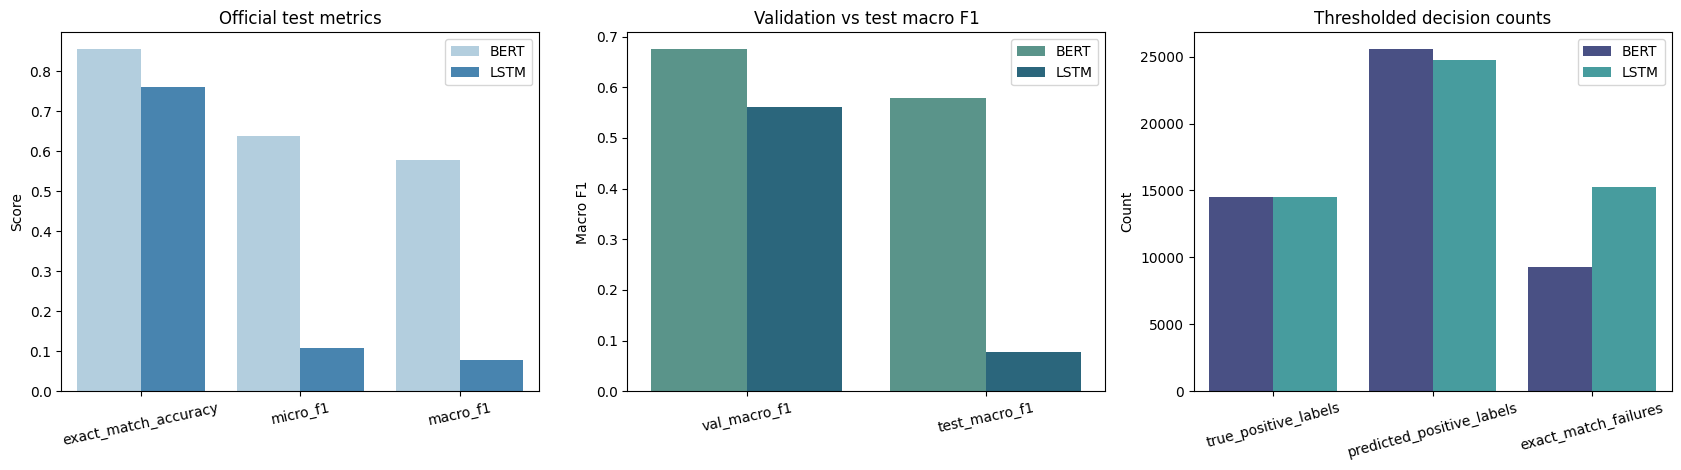

**Why can LSTM show a relatively low loss but very weak precision / recall / F1?**

- This task uses sparse multilabel BCE loss, so the average loss is dominated by many easy negative labels. A model can keep BCE low without producing good thresholded decisions on the positive labels.
- The LSTM does not collapse to predicting only negatives. Instead, it predicts many positive labels, but most of them are wrong. That is why precision and recall both stay poor after thresholding.
- BERT preserves much better ranking and calibration of the positive labels, so the validation macro F1 and the final test macro F1 remain much stronger.

**Official held-out test summary**

,model,exact_match_accuracy,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1
0,BERT,0.8545,0.5005,0.8816,0.6385,0.4546,0.8225,0.5787
1,LSTM,0.7611,0.0854,0.1456,0.1077,0.0651,0.0994,0.0773


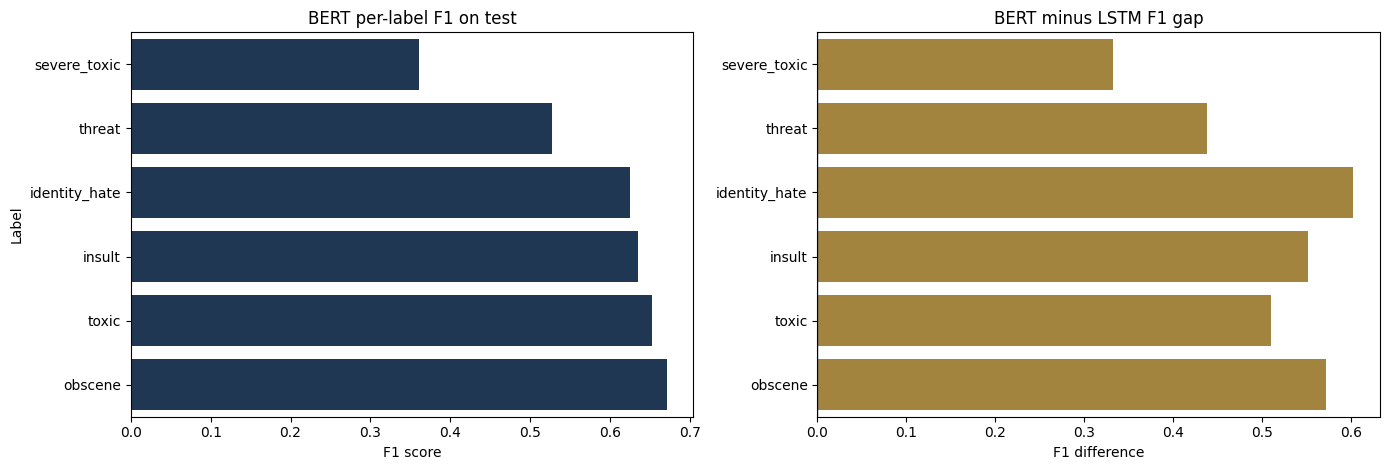

**Per-label metric reference table**

,label,bert_precision,bert_recall,bert_f1,lstm_precision,lstm_recall,lstm_f1
0,toxic,0.5044,0.9225,0.6522,0.1128,0.1913,0.1420
1,severe_toxic,0.2361,0.7657,0.3610,0.0215,0.0436,0.0288
2,obscene,0.5444,0.8740,0.6709,0.0755,0.1412,0.0983
3,threat,0.4051,0.7583,0.5281,0.0947,0.0853,0.0898
4,insult,0.5027,0.8643,0.6357,0.0675,0.1085,0.0832
5,identity_hate,0.5351,0.7500,0.6246,0.0183,0.0267,0.0217


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

def locate_repo_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "btl1" / "artifacts" / "text").exists():
            return base
    raise FileNotFoundError("Could not locate repo root for text artifacts.")

REPO_ROOT = locate_repo_root()
ARTIFACT_DIR = REPO_ROOT / "btl1" / "artifacts" / "text"

metrics_payload = json.loads((ARTIFACT_DIR / "text_metrics_summary.json").read_text(encoding="utf-8"))
comparison_df = pd.read_csv(ARTIFACT_DIR / "text_model_comparison.csv")
per_label_df = pd.read_csv(ARTIFACT_DIR / "text_per_label_metrics.csv")
error_payload = json.loads((ARTIFACT_DIR / "text_error_analysis.json").read_text(encoding="utf-8"))

protocol_specs = [
    ("BERT", "bert_multilabel_best.pt", "bert_history.csv", "bert"),
    ("LSTM", "lstm_multilabel_best.pt", "lstm_history.csv", "lstm"),
    ("BERT_head_only_weighted", "bert_head_only_weighted_best.pt", "bert_head_only_weighted_history.csv", "bert_head_only_weighted"),
]
protocol_rows = []
val_test_rows = []
for model_name, checkpoint_name, history_name, payload_key in protocol_specs:
    checkpoint_path = ARTIFACT_DIR / checkpoint_name
    history_path = ARTIFACT_DIR / history_name
    if not checkpoint_path.exists() or not history_path.exists() or payload_key not in metrics_payload:
        continue
    history_df = pd.read_csv(history_path)
    protocol_rows.append({
        "model": model_name,
        "checkpoint": checkpoint_name,
        "best_val_macro_f1": float(history_df["val_macro_f1"].max()),
        "latest_val_loss": float(history_df.iloc[-1]["val_loss"]),
    })
    val_test_rows.append({
        "model": model_name,
        "val_macro_f1": float(history_df["val_macro_f1"].max()),
        "test_macro_f1": float(metrics_payload[payload_key]["macro_f1"]),
        "val_loss": float(history_df["val_loss"].min()),
        "test_loss": float(metrics_payload[payload_key]["loss"]),
    })

protocol_df = pd.DataFrame(protocol_rows)
val_test_df = pd.DataFrame(val_test_rows)
display(Markdown("**Checkpoint provenance**"))
display(protocol_df.round(4))

comparison_df = comparison_df.copy()
comparison_df["family"] = comparison_df["model"].map(lambda name: "BERT" if str(name).startswith("BERT") else "LSTM")
comparison_df["strategy"] = comparison_df["model"].map(lambda name: "head_only_weighted" if "head_only" in str(name).lower() else ("full_finetune" if str(name).startswith("BERT") else "train_from_scratch"))

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

summary_long = comparison_df.melt(id_vars=["model", "family", "strategy"], value_vars=["exact_match_accuracy", "micro_f1", "macro_f1"], var_name="metric", value_name="score")
sns.barplot(data=summary_long, x="metric", y="score", hue="model", palette="Blues", ax=axes[0, 0])
axes[0, 0].set_title("Test metrics by branch")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Score")
axes[0, 0].tick_params(axis="x", rotation=12)

family_df = comparison_df.groupby("family", as_index=False)[["exact_match_accuracy", "micro_f1", "macro_f1"]].max()
family_long = family_df.melt(id_vars="family", var_name="metric", value_name="score")
sns.barplot(data=family_long, x="metric", y="score", hue="family", palette="crest", ax=axes[0, 1])
axes[0, 1].set_title("Best score by model family")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Score")
axes[0, 1].tick_params(axis="x", rotation=12)

strategy_long = comparison_df.melt(id_vars=["strategy"], value_vars=["exact_match_accuracy", "micro_f1", "macro_f1"], var_name="metric", value_name="score")
sns.barplot(data=strategy_long, x="metric", y="score", hue="strategy", palette="mako", ax=axes[1, 0])
axes[1, 0].set_title("Test metrics by training strategy")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Score")
axes[1, 0].tick_params(axis="x", rotation=12)

if not val_test_df.empty:
    val_test_long = val_test_df.melt(id_vars="model", value_vars=["val_macro_f1", "test_macro_f1"], var_name="metric", value_name="score")
    sns.barplot(data=val_test_long, x="metric", y="score", hue="model", palette="viridis", ax=axes[1, 1])
    axes[1, 1].set_title("Validation vs test macro F1")
    axes[1, 1].set_xlabel("")
    axes[1, 1].set_ylabel("Macro F1")
    axes[1, 1].tick_params(axis="x", rotation=12)

for ax in axes.flatten():
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="best")
fig.tight_layout()
plt.show()
plt.close(fig)

display(Markdown("**Held-out test summary**"))
display(comparison_df.round(4))

### Optional BERT Full vs Head-Only Weighted Comparison

If the head-only branch above has been executed, this cell compares `BERT full fine-tune`, `BERT head-only weighted`, and `LSTM` side by side.

In [ ]:
if "bert_head_only_metrics" not in globals():
    print("BERT head-only weighted has not been run in this notebook session yet.")
else:
    bert_strategy_df = pd.DataFrame([
        {"model": "BERT full fine-tune", **bert_metrics},
        {"model": "BERT head-only weighted", **bert_head_only_metrics},
        {"model": "LSTM", **lstm_metrics},
    ])
    display(bert_strategy_df.round(4))

    bert_strategy_long = bert_strategy_df.melt(
        id_vars="model",
        value_vars=["exact_match_accuracy", "micro_f1", "macro_f1"],
        var_name="metric",
        value_name="score",
    )
    fig, ax = plt.subplots(figsize=(10, 4.8))
    sns.barplot(data=bert_strategy_long, x="metric", y="score", hue="model", palette="Blues", ax=ax)
    ax.set_title("Text training-strategy comparison")
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=12)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
